# Model Interpretation – XGBoost


## 1. Zielsetzung und methodische Einordnung

Notebook 02 untersucht das in Notebook 01 festgelegte getunte XGBoost-Modell. Es findet keine erneute Modellauswahl, keine weitere Hyperparametersuche und kein Vergleich mit anderen Modellklassen statt.

Die Analyse betrachtet ausschließlich die prognostische Bedeutung der externen Zeit-, Kalender- und Wettermerkmale für die Modellvorhersage. Die Ergebnisse beschreiben modellierte Zusammenhänge und Modellbeiträge innerhalb des XGBoost-Modells. Sie sind nicht als kausale Effekte zu verstehen.

Die Methodik bleibt unverändert: Training auf Januar bis April 2026, Validierung und Interpretation auf Mai 2026. Der Testdatensatz Juni 2026 wird nicht geladen oder verwendet.


## 2. Setup


In [14]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from xgboost import XGBRegressor


PROJECT_DIR = Path.cwd()

while not (PROJECT_DIR / "datasets").exists():
    if PROJECT_DIR == PROJECT_DIR.parent:
        raise FileNotFoundError("Could not find project directory with datasets/.")
    PROJECT_DIR = PROJECT_DIR.parent

TRAIN_PATH = PROJECT_DIR / "datasets" / "modeling" / "features" / "train_features.parquet"
VALIDATION_PATH = PROJECT_DIR / "datasets" / "modeling" / "features" / "validation_features.parquet"


## 3. Daten laden


In [15]:
train = pd.read_parquet(TRAIN_PATH)
validation = pd.read_parquet(VALIDATION_PATH)

external_features = [
    "event_hour",
    "event_weekday",
    "is_public_holiday",
    "ff_wind_speed_ms",
    "wind_direction_sin",
    "wind_direction_cos",
    "fx_wind_gust_ms",
    "tu_temperature_c",
    "tu_relative_humidity_pct",
    "rr_precipitation_mm",
    "rr_precipitation_indicator",
    "rr_precipitation_form",
]

y_train = train["delay_target"]
y_validation = validation["delay_target"]

X_train = train[external_features].copy()
X_validation = validation[external_features].copy()

pd.DataFrame(
    {
        "Dataset": ["Training", "Validation"],
        "Period": ["Januar bis April 2026", "Mai 2026"],
        "Observations": [len(train), len(validation)],
        "Features": [X_train.shape[1], X_validation.shape[1]],
    }
)


,Dataset,Period,Observations,Features
0,Training,Januar bis April 2026,353835,12
1,Validation,Mai 2026,86644,12


## 4. Features und Preprocessing

Die Feature-Aufbereitung entspricht der XGBoost-Aufbereitung aus Notebook 01: numerische Merkmale werden mit dem Trainingsmedian imputiert, kategoriale Merkmale werden nach einer einheitlichen Missing-Value-Behandlung per One-Hot-Encoding verarbeitet.


In [16]:
categorical_features = [
    "event_hour",
    "event_weekday",
    "rr_precipitation_form",
]

numeric_features = [
    "is_public_holiday",
    "ff_wind_speed_ms",
    "wind_direction_sin",
    "wind_direction_cos",
    "fx_wind_gust_ms",
    "tu_temperature_c",
    "tu_relative_humidity_pct",
    "rr_precipitation_mm",
    "rr_precipitation_indicator",
]

model_features = categorical_features + numeric_features

X_train_model = X_train[model_features].copy()
X_validation_model = X_validation[model_features].copy()

for column in categorical_features:
    X_train_model[column] = X_train_model[column].fillna("missing").astype(str)
    X_validation_model[column] = X_validation_model[column].fillna("missing").astype(str)

numeric_transformer = SimpleImputer(strategy="median")
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features),
    ]
)

feature_overview = pd.DataFrame(
    {
        "Feature": model_features,
        "Feature Type": [
            "categorical" if feature in categorical_features else "numeric"
            for feature in model_features
        ],
    }
)

feature_overview


,Feature,Feature Type
0,event_hour,categorical
1,event_weekday,categorical
2,rr_precipitation_form,categorical
3,is_public_holiday,numeric
4,ff_wind_speed_ms,numeric
5,wind_direction_sin,numeric
6,wind_direction_cos,numeric
7,fx_wind_gust_ms,numeric
8,tu_temperature_c,numeric
9,tu_relative_humidity_pct,numeric


## 5. Getuntes XGBoost-Modell rekonstruieren

Die folgenden Hyperparameter entsprechen der in Notebook 01 gespeicherten besten XGBoost-Konfiguration nach dem dort begrenzten Tuning. In diesem Notebook werden diese Werte nur übernommen; es findet keine erneute Suche statt.


In [17]:
xgboost_tuned_params = {
    "n_estimators": 200,
    "max_depth": 3,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": -1,
}

xgboost_tuned_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(**xgboost_tuned_params)),
    ]
)

xgboost_tuned_pipeline.fit(X_train_model, y_train)

xgboost_tuned_params


{'n_estimators': 200,
 'max_depth': 3,
 'learning_rate': 0.05,
 'subsample': 0.8,
 'colsample_bytree': 0.8,
 'objective': 'reg:squarederror',
 'tree_method': 'hist',
 'random_state': 42,
 'n_jobs': -1}

## 6. Validierungsleistung überprüfen

Die Validierungsleistung wird auf dem vollständigen Mai-Datensatz berechnet. Dieser Schritt dient nur als Reproduktionskontrolle der in Notebook 01 festgelegten XGBoost-Konfiguration.


In [18]:
xgboost_validation_predictions = xgboost_tuned_pipeline.predict(X_validation_model)

xgboost_validation_mae = mean_absolute_error(
    y_validation,
    xgboost_validation_predictions,
)
xgboost_validation_rmse = np.sqrt(
    mean_squared_error(y_validation, xgboost_validation_predictions)
)
xgboost_validation_r2 = r2_score(y_validation, xgboost_validation_predictions)

validation_performance = pd.DataFrame(
    {
        "Metric": ["MAE", "RMSE", "R2"],
        "Value": [
            xgboost_validation_mae,
            xgboost_validation_rmse,
            xgboost_validation_r2,
        ],
    }
)

validation_performance.round(3)


,Metric,Value
0,MAE,5.591
1,RMSE,9.499
2,R2,0.015


## 7. Gruppierte Permutation Importance

Die Modellinterpretation wird auf dem vollständigen Validierungsdatensatz Mai 2026 durchgeführt. Dadurch basieren sowohl die Permutation Importance als auch die Partial-Dependence-Auswertungen auf allen im Validierungszeitraum verfügbaren Beobachtungen.

Die Permutation Importance wird auf Ebene der ursprünglichen fachlichen Einflussfaktoren berechnet. One-Hot-Spalten werden nicht einzeln interpretiert. Die Windrichtung wird als gemeinsames Sinus-/Cosinus-Paar behandelt.


In [19]:
X_interpretation = X_validation_model.copy()
y_interpretation = y_validation.copy()

pd.DataFrame(
    {
        "Metric": ["Interpretation observations"],
        "Value": [len(X_interpretation)],
    }
)


,Metric,Value
0,Interpretation observations,86644


In [20]:
interpretation_groups = {
    "Tageszeit": ["event_hour"],
    "Wochentag": ["event_weekday"],
    "Feiertag": ["is_public_holiday"],
    "Windgeschwindigkeit": ["ff_wind_speed_ms"],
    "Windrichtung": ["wind_direction_sin", "wind_direction_cos"],
    "Windböen": ["fx_wind_gust_ms"],
    "Temperatur": ["tu_temperature_c"],
    "Relative Luftfeuchtigkeit": ["tu_relative_humidity_pct"],
    "Niederschlagsmenge": ["rr_precipitation_mm"],
    "Niederschlagsindikator": ["rr_precipitation_indicator"],
    "Niederschlagsform": ["rr_precipitation_form"],
}

baseline_interpretation_predictions = xgboost_tuned_pipeline.predict(X_interpretation)
baseline_interpretation_r2 = r2_score(
    y_interpretation,
    baseline_interpretation_predictions,
)


def calculate_grouped_permutation_importance(
    model: Pipeline,
    X: pd.DataFrame,
    y: pd.Series,
    groups: dict[str, list[str]],
    baseline_r2: float,
    n_repeats: int = 10,
    random_state: int = 42,
) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)
    rows = []

    for factor, columns in groups.items():
        importance_values = []

        for _ in range(n_repeats):
            X_permuted = X.copy()
            permutation = rng.permutation(len(X_permuted))

            for column in columns:
                X_permuted[column] = X_permuted[column].to_numpy()[permutation]

            permuted_predictions = model.predict(X_permuted)
            permuted_r2 = r2_score(y, permuted_predictions)
            importance_values.append(baseline_r2 - permuted_r2)

        rows.append(
            {
                "Factor": factor,
                "Importance Mean": float(np.mean(importance_values)),
                "Importance Std": float(np.std(importance_values, ddof=1)),
            }
        )

    return (
        pd.DataFrame(rows)
        .sort_values("Importance Mean", ascending=False)
        .reset_index(drop=True)
    )


permutation_importance_results = calculate_grouped_permutation_importance(
    model=xgboost_tuned_pipeline,
    X=X_interpretation,
    y=y_interpretation,
    groups=interpretation_groups,
    baseline_r2=baseline_interpretation_r2,
    n_repeats=10,
    random_state=42,
)

permutation_importance_results.round(4)


,Factor,Importance Mean,Importance Std
0,Tageszeit,0.0157,0.0006
1,Wochentag,0.0156,0.0006
2,Temperatur,0.0137,0.0006
3,Relative Luftfeuchtigkeit,0.0046,0.0005
4,Windgeschwindigkeit,0.0007,0.0001
5,Niederschlagsmenge,-0.0000,0.0001
6,Feiertag,-0.0001,0.0002
7,Niederschlagsform,-0.0002,0.0001
8,Windböen,-0.0004,0.0002
9,Niederschlagsindikator,-0.0007,0.0002


## 8. Visualisierung der Permutation Importance


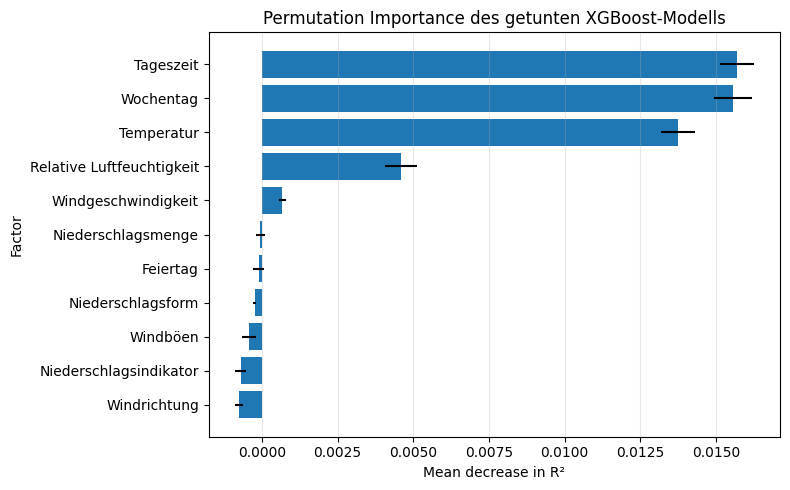

,Factor,Importance Mean,Importance Std
0,Tageszeit,0.0157,0.0006
1,Wochentag,0.0156,0.0006
2,Temperatur,0.0137,0.0006
3,Relative Luftfeuchtigkeit,0.0046,0.0005
4,Windgeschwindigkeit,0.0007,0.0001
5,Niederschlagsmenge,-0.0000,0.0001
6,Feiertag,-0.0001,0.0002
7,Niederschlagsform,-0.0002,0.0001
8,Windböen,-0.0004,0.0002
9,Niederschlagsindikator,-0.0007,0.0002


In [21]:
plot_data = permutation_importance_results.sort_values(
    "Importance Mean",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    plot_data["Factor"],
    plot_data["Importance Mean"],
    xerr=plot_data["Importance Std"],
)
ax.set_title("Permutation Importance des getunten XGBoost-Modells")
ax.set_xlabel("Mean decrease in R²")
ax.set_ylabel("Factor")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

permutation_importance_results.round(4)


## 9. Partial-Dependence-Analyse

Partial Dependence beschreibt die Reaktion des Modells auf Änderungen eines Merkmals, während alle anderen Merkmale unverändert bleiben. Sie ist kein kausaler Effekt. Korrelationen zwischen Wettervariablen können außerdem unrealistische Merkmalskombinationen erzeugen. Die Ergebnisse sind deshalb vorsichtig als modellierte Zusammenhänge zu lesen.


In [22]:
def calculate_numeric_partial_dependence(
    model: Pipeline,
    X: pd.DataFrame,
    feature: str,
    values: np.ndarray,
) -> pd.DataFrame:
    rows = []

    for value in values:
        X_modified = X.copy()
        X_modified[feature] = value
        mean_prediction = float(np.mean(model.predict(X_modified)))
        rows.append({"Feature": feature, "Value": value, "Mean Prediction": mean_prediction})

    return pd.DataFrame(rows)


def calculate_categorical_partial_dependence(
    model: Pipeline,
    X: pd.DataFrame,
    feature: str,
    values: list,
    display_values: list | None = None,
) -> pd.DataFrame:
    if display_values is None:
        display_values = values

    rows = []

    for assigned_value, display_value in zip(values, display_values):
        X_modified = X.copy()
        X_modified[feature] = assigned_value
        mean_prediction = float(np.mean(model.predict(X_modified)))
        rows.append(
            {
                "Feature": feature,
                "Value": display_value,
                "Assigned Value": assigned_value,
                "Mean Prediction": mean_prediction,
            }
        )

    return pd.DataFrame(rows)


def calculate_wind_direction_partial_dependence(
    model: Pipeline,
    X: pd.DataFrame,
    angles_degrees: list[int],
) -> pd.DataFrame:
    rows = []

    for angle_degrees in angles_degrees:
        angle_radians = np.deg2rad(angle_degrees)
        X_modified = X.copy()
        X_modified["wind_direction_sin"] = np.sin(angle_radians)
        X_modified["wind_direction_cos"] = np.cos(angle_radians)
        mean_prediction = float(np.mean(model.predict(X_modified)))
        rows.append(
            {
                "Wind Direction Degrees": angle_degrees,
                "Mean Prediction": mean_prediction,
            }
        )

    return pd.DataFrame(rows)


def evenly_spaced_quantile_grid(
    series: pd.Series,
    lower_quantile: float = 0.05,
    upper_quantile: float = 0.95,
    n_values: int = 20,
) -> np.ndarray:
    numeric_series = pd.to_numeric(series, errors="coerce").dropna()
    lower = numeric_series.quantile(lower_quantile)
    upper = numeric_series.quantile(upper_quantile)

    if np.isclose(lower, upper):
        return np.array([float(lower)])

    return np.linspace(lower, upper, n_values)


def observed_quantile_grid(
    series: pd.Series,
    lower_quantile: float = 0.05,
    upper_quantile: float = 0.95,
    n_values: int = 20,
) -> np.ndarray:
    numeric_series = pd.to_numeric(series, errors="coerce").dropna()
    quantiles = np.linspace(lower_quantile, upper_quantile, n_values)
    values = numeric_series.quantile(quantiles).to_numpy()
    values = np.unique(values)

    if len(values) > 1:
        return values

    lower = numeric_series.quantile(lower_quantile)
    upper = numeric_series.quantile(upper_quantile)
    observed_values = np.sort(
        numeric_series[(numeric_series >= lower) & (numeric_series <= upper)].unique()
    )

    if len(observed_values) <= n_values:
        return observed_values.astype(float)

    selected_positions = np.linspace(0, len(observed_values) - 1, n_values).round().astype(int)
    return observed_values[selected_positions].astype(float)


def sorted_observed_values(series: pd.Series) -> list:
    values = pd.Series(series.dropna().unique())
    return values.sort_values().tolist()


### 9.1 Zeit- und Kalenderfaktoren

Die Wochentagskodierung basiert auf `pandas.Series.dt.weekday`: 0 = Montag, 1 = Dienstag, 2 = Mittwoch, 3 = Donnerstag, 4 = Freitag, 5 = Samstag, 6 = Sonntag.


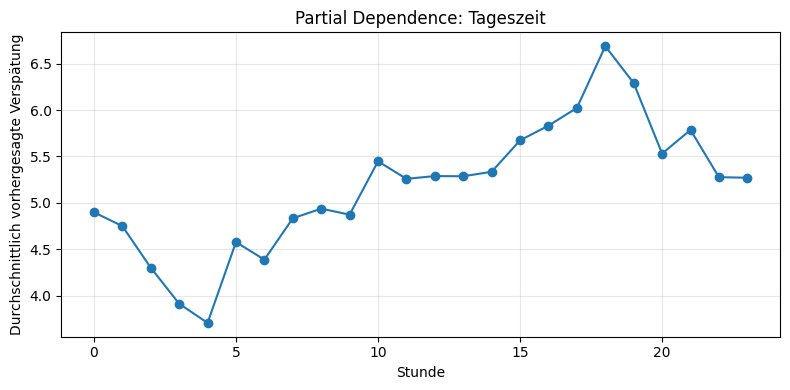

,Feature,Value,Assigned Value,Mean Prediction
0,event_hour,0,0,4.899
1,event_hour,1,1,4.751
2,event_hour,2,2,4.303
3,event_hour,3,3,3.915
4,event_hour,4,4,3.709
5,event_hour,5,5,4.579
6,event_hour,6,6,4.389
7,event_hour,7,7,4.835
8,event_hour,8,8,4.939
9,event_hour,9,9,4.874


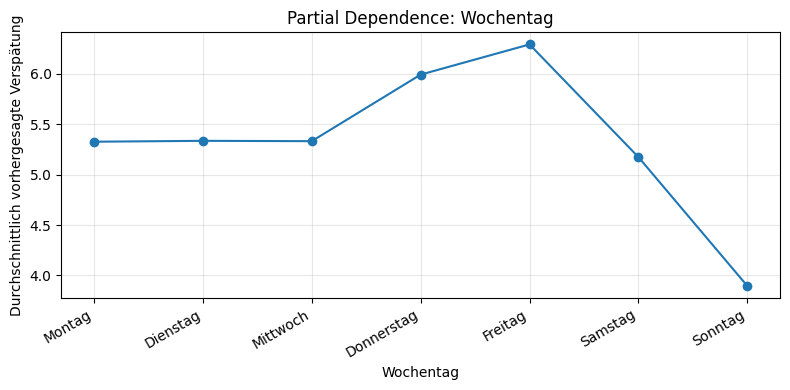

,Feature,Value,Assigned Value,Mean Prediction
0,event_weekday,0,0,5.328
1,event_weekday,1,1,5.336
2,event_weekday,2,2,5.333
3,event_weekday,3,3,5.994
4,event_weekday,4,4,6.293
5,event_weekday,5,5,5.175
6,event_weekday,6,6,3.896


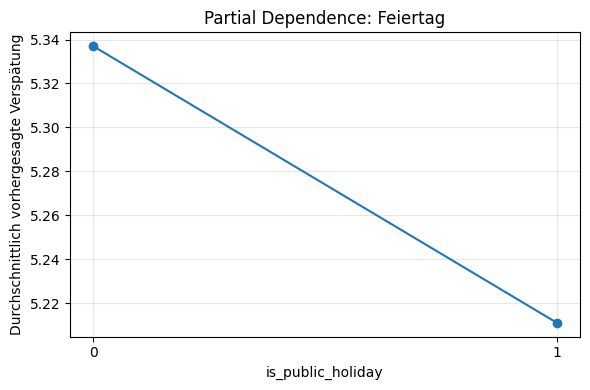

,Feature,Value,Assigned Value,Mean Prediction
0,is_public_holiday,False,False,5.337
1,is_public_holiday,True,True,5.211


In [23]:
event_hour_values = list(range(24))
event_hour_pd = calculate_categorical_partial_dependence(
    model=xgboost_tuned_pipeline,
    X=X_interpretation,
    feature="event_hour",
    values=[str(value) for value in event_hour_values],
    display_values=event_hour_values,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(event_hour_pd["Value"], event_hour_pd["Mean Prediction"], marker="o")
ax.set_title("Partial Dependence: Tageszeit")
ax.set_xlabel("Stunde")
ax.set_ylabel("Durchschnittlich vorhergesagte Verspätung")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(event_hour_pd.round(3))

event_weekday_values = list(range(7))
weekday_labels = [
    "Montag",
    "Dienstag",
    "Mittwoch",
    "Donnerstag",
    "Freitag",
    "Samstag",
    "Sonntag",
]
event_weekday_pd = calculate_categorical_partial_dependence(
    model=xgboost_tuned_pipeline,
    X=X_interpretation,
    feature="event_weekday",
    values=[str(value) for value in event_weekday_values],
    display_values=event_weekday_values,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(event_weekday_pd["Value"], event_weekday_pd["Mean Prediction"], marker="o")
ax.set_title("Partial Dependence: Wochentag")
ax.set_xlabel("Wochentag")
ax.set_ylabel("Durchschnittlich vorhergesagte Verspätung")
ax.set_xticks(event_weekday_values)
ax.set_xticklabels(weekday_labels, rotation=30, ha="right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(event_weekday_pd.round(3))

holiday_values = sorted_observed_values(X_train_model["is_public_holiday"])
is_public_holiday_pd = calculate_categorical_partial_dependence(
    model=xgboost_tuned_pipeline,
    X=X_interpretation,
    feature="is_public_holiday",
    values=holiday_values,
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(is_public_holiday_pd["Value"], is_public_holiday_pd["Mean Prediction"], marker="o")
ax.set_title("Partial Dependence: Feiertag")
ax.set_xlabel("is_public_holiday")
ax.set_ylabel("Durchschnittlich vorhergesagte Verspätung")
ax.set_xticks(holiday_values)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

is_public_holiday_pd.round(3)


### 9.2 Temperatur und Luftfeuchtigkeit


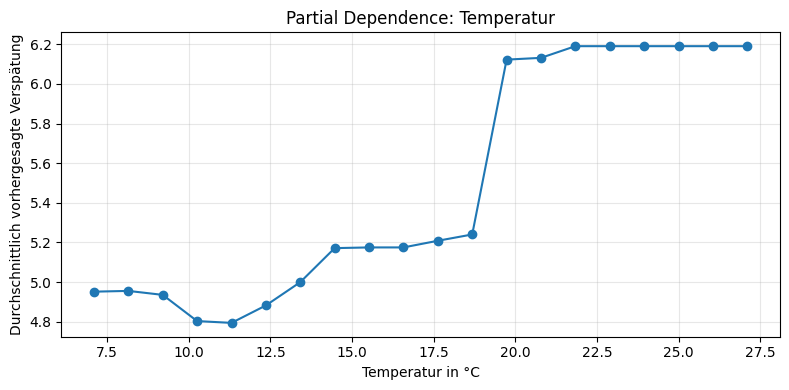

,Feature,Value,Mean Prediction
0,tu_temperature_c,7.100,4.952
1,tu_temperature_c,8.153,4.956
2,tu_temperature_c,9.205,4.936
3,tu_temperature_c,10.258,4.804
4,tu_temperature_c,11.311,4.795
5,tu_temperature_c,12.363,4.883
6,tu_temperature_c,13.416,5.000
7,tu_temperature_c,14.468,5.172
8,tu_temperature_c,15.521,5.175
9,tu_temperature_c,16.574,5.175


In [24]:
temperature_grid = evenly_spaced_quantile_grid(X_interpretation["tu_temperature_c"])
temperature_pd = calculate_numeric_partial_dependence(
    model=xgboost_tuned_pipeline,
    X=X_interpretation,
    feature="tu_temperature_c",
    values=temperature_grid,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(temperature_pd["Value"], temperature_pd["Mean Prediction"], marker="o")
ax.set_title("Partial Dependence: Temperatur")
ax.set_xlabel("Temperatur in °C")
ax.set_ylabel("Durchschnittlich vorhergesagte Verspätung")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(temperature_pd.round(3))


#### Detailanalyse des Temperatursprungs

Die grobe Partial-Dependence-Kurve zeigt im Bereich von etwa 18–20 °C einen deutlichen Sprung der durchschnittlichen Modellvorhersage. Da XGBoost auf Entscheidungsbäumen basiert und daher Schwellenwerte lernen kann, wird dieser Temperaturbereich im Folgenden mit einer feineren Auflösung untersucht. Zusätzlich werden die im XGBoost-Modell verwendeten Split-Schwellen der Temperaturvariable sowie die Datenabdeckung in diesem Bereich betrachtet.


In [25]:
temperature_detail_values = np.round(
    np.arange(17.0, 21.0 + 0.0001, 0.1),
    1,
)

temperature_detail_rows = []

for temperature_c in temperature_detail_values:
    X_temperature_detail = X_interpretation.copy()
    X_temperature_detail["tu_temperature_c"] = temperature_c
    mean_predicted_delay = float(
        np.mean(xgboost_tuned_pipeline.predict(X_temperature_detail))
    )
    temperature_detail_rows.append(
        {
            "Temperature_C": temperature_c,
            "Mean_Predicted_Delay": mean_predicted_delay,
        }
    )

temperature_detail_pd = pd.DataFrame(temperature_detail_rows)

temperature_detail_pd.round(3)


,Temperature_C,Mean_Predicted_Delay
0,17.0,5.209
1,17.1,5.209
2,17.2,5.209
3,17.3,5.209
4,17.4,5.209
5,17.5,5.209
6,17.6,5.209
7,17.7,5.219
8,17.8,5.219
9,17.9,5.219


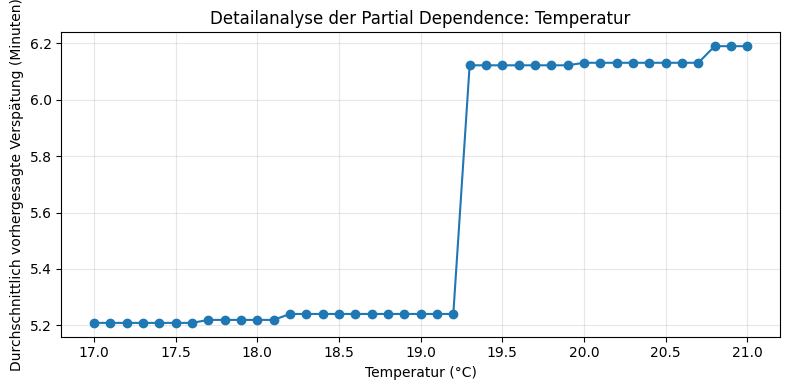

In [26]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    temperature_detail_pd["Temperature_C"],
    temperature_detail_pd["Mean_Predicted_Delay"],
    marker="o",
)
ax.set_title("Detailanalyse der Partial Dependence: Temperatur")
ax.set_xlabel("Temperatur (°C)")
ax.set_ylabel("Durchschnittlich vorhergesagte Verspätung (Minuten)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [27]:
fitted_preprocessor = xgboost_tuned_pipeline.named_steps["preprocessor"]
transformed_feature_names = fitted_preprocessor.get_feature_names_out()

temperature_feature_matches = [
    index
    for index, feature_name in enumerate(transformed_feature_names)
    if feature_name == "tu_temperature_c"
    or feature_name.endswith("__tu_temperature_c")
]

if len(temperature_feature_matches) != 1:
    raise ValueError(
        "Expected exactly one transformed temperature feature, "
        f"found {len(temperature_feature_matches)}."
    )

temperature_feature_index = temperature_feature_matches[0]
temperature_transformed_feature = transformed_feature_names[temperature_feature_index]

xgboost_model = xgboost_tuned_pipeline.named_steps["model"]
booster = xgboost_model.get_booster()
booster_feature_names = booster.feature_names

if booster_feature_names is None:
    temperature_booster_feature = f"f{temperature_feature_index}"
elif temperature_transformed_feature in booster_feature_names:
    temperature_booster_feature = temperature_transformed_feature
else:
    temperature_booster_feature = booster_feature_names[temperature_feature_index]

trees = booster.trees_to_dataframe()
temperature_split_rows = trees.loc[
    trees["Feature"] == temperature_booster_feature,
    ["Split"],
].dropna()

temperature_split_thresholds = (
    temperature_split_rows.assign(Split=temperature_split_rows["Split"].round(3))
    .groupby("Split", as_index=False)
    .size()
    .rename(columns={"size": "Count"})
    .sort_values("Split", ascending=True)
    .reset_index(drop=True)
)

temperature_split_thresholds_near_jump = (
    temperature_split_thresholds.loc[
        temperature_split_thresholds["Split"].between(17.0, 21.0, inclusive="both")
    ]
    .sort_values("Count", ascending=False)
    .reset_index(drop=True)
)

display(temperature_split_thresholds)

temperature_split_thresholds_near_jump


,Split,Count
0,-4.5,4
1,-3.6,1
2,-2.7,1
3,-2.0,8
4,-1.6,12
...,...,...
76,17.7,1
77,18.2,3
78,19.3,10
79,20.0,2


,Split,Count
0,19.3,10
1,17.0,4
2,18.2,3
3,20.0,2
4,17.7,1
5,20.8,1


In [28]:
def calculate_temperature_coverage(
    dataset_name: str,
    features: pd.DataFrame,
) -> dict:
    temperature = pd.to_numeric(features["tu_temperature_c"], errors="coerce")
    observations_total = len(temperature)
    observations_17_21 = int(
        temperature.between(17.0, 21.0, inclusive="both").sum()
    )
    observations_above_19 = int((temperature > 19.0).sum())

    return {
        "Dataset": dataset_name,
        "Observations_Total": observations_total,
        "Observations_17_21": observations_17_21,
        "Share_17_21_Percent": observations_17_21 / observations_total * 100,
        "Observations_Above_19": observations_above_19,
        "Share_Above_19_Percent": observations_above_19 / observations_total * 100,
        "Temperature_Missing": int(temperature.isna().sum()),
        "Temperature_Min": temperature.min(),
        "Temperature_Q05": temperature.quantile(0.05),
        "Temperature_Median": temperature.median(),
        "Temperature_Q95": temperature.quantile(0.95),
        "Temperature_Max": temperature.max(),
    }


temperature_coverage = pd.DataFrame(
    [
        calculate_temperature_coverage("Training", X_train),
        calculate_temperature_coverage("Validation", X_validation),
    ]
)

temperature_coverage.round(3)


,Dataset,Observations_Total,Observations_17_21,Share_17_21_Percent,Observations_Above_19,Share_Above_19_Percent,Temperature_Missing,Temperature_Min,Temperature_Q05,Temperature_Median,Temperature_Q95,Temperature_Max
0,Training,353835,21232,6.001,6680,1.888,0,-12.8,-0.5,7.3,17.4,22.6
1,Validation,86644,14390,16.608,26290,30.343,0,3.2,7.1,15.1,27.1,31.6


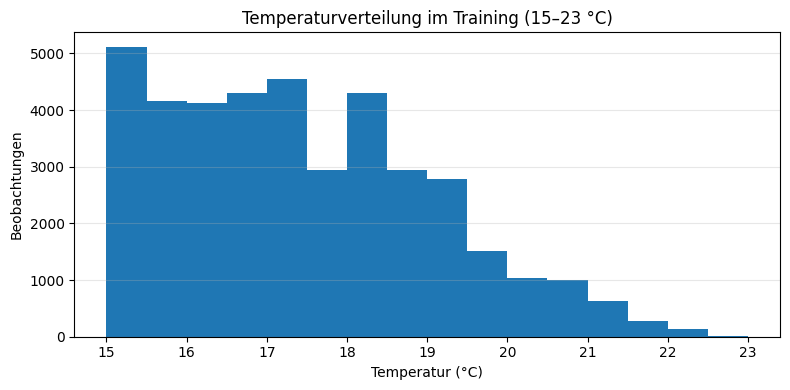

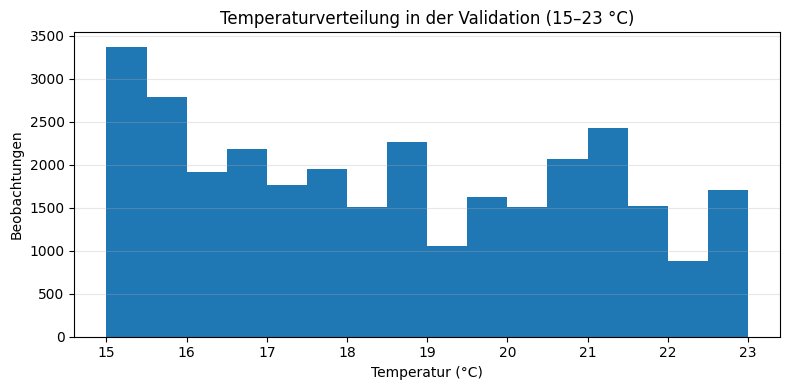

In [29]:
temperature_histogram_bins = np.arange(15.0, 23.0 + 0.5, 0.5)

training_temperature_focus = pd.to_numeric(
    X_train["tu_temperature_c"],
    errors="coerce",
).dropna()
training_temperature_focus = training_temperature_focus[
    training_temperature_focus.between(15.0, 23.0, inclusive="both")
]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(training_temperature_focus, bins=temperature_histogram_bins)
ax.set_title("Temperaturverteilung im Training (15–23 °C)")
ax.set_xlabel("Temperatur (°C)")
ax.set_ylabel("Beobachtungen")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

validation_temperature_focus = pd.to_numeric(
    X_validation["tu_temperature_c"],
    errors="coerce",
).dropna()
validation_temperature_focus = validation_temperature_focus[
    validation_temperature_focus.between(15.0, 23.0, inclusive="both")
]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(validation_temperature_focus, bins=temperature_histogram_bins)
ax.set_title("Temperaturverteilung in der Validation (15–23 °C)")
ax.set_xlabel("Temperatur (°C)")
ax.set_ylabel("Beobachtungen")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


Die Detailanalyse dient dazu zu prüfen, ob der sichtbare Temperatursprung mit konkreten XGBoost-Split-Schwellen zusammenfällt und ob der betreffende Temperaturbereich in den Trainings- und Validierungsdaten ausreichend beobachtet wurde. Die Ergebnisse sind als Modellverhalten und nicht als kausaler Temperatureffekt zu interpretieren.


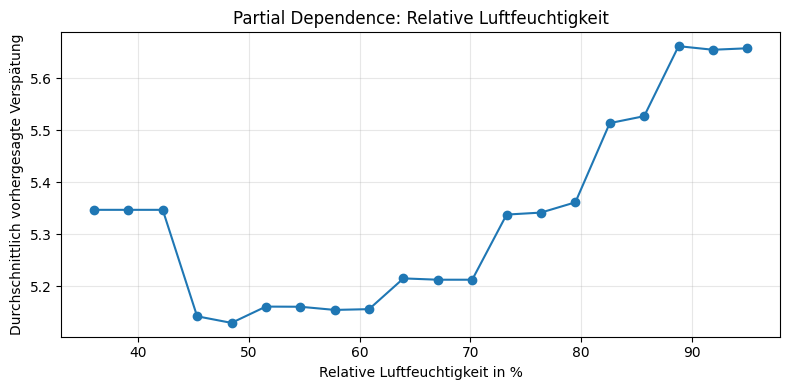

,Feature,Value,Mean Prediction
0,tu_relative_humidity_pct,36.000,5.347
1,tu_relative_humidity_pct,39.105,5.347
2,tu_relative_humidity_pct,42.211,5.347
3,tu_relative_humidity_pct,45.316,5.143
4,tu_relative_humidity_pct,48.421,5.130
5,tu_relative_humidity_pct,51.526,5.161
6,tu_relative_humidity_pct,54.632,5.161
7,tu_relative_humidity_pct,57.737,5.155
8,tu_relative_humidity_pct,60.842,5.156
9,tu_relative_humidity_pct,63.947,5.216


In [30]:
humidity_grid = evenly_spaced_quantile_grid(X_interpretation["tu_relative_humidity_pct"])
humidity_pd = calculate_numeric_partial_dependence(
    model=xgboost_tuned_pipeline,
    X=X_interpretation,
    feature="tu_relative_humidity_pct",
    values=humidity_grid,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(humidity_pd["Value"], humidity_pd["Mean Prediction"], marker="o")
ax.set_title("Partial Dependence: Relative Luftfeuchtigkeit")
ax.set_xlabel("Relative Luftfeuchtigkeit in %")
ax.set_ylabel("Durchschnittlich vorhergesagte Verspätung")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

humidity_pd.round(3)


### 9.3 Wind


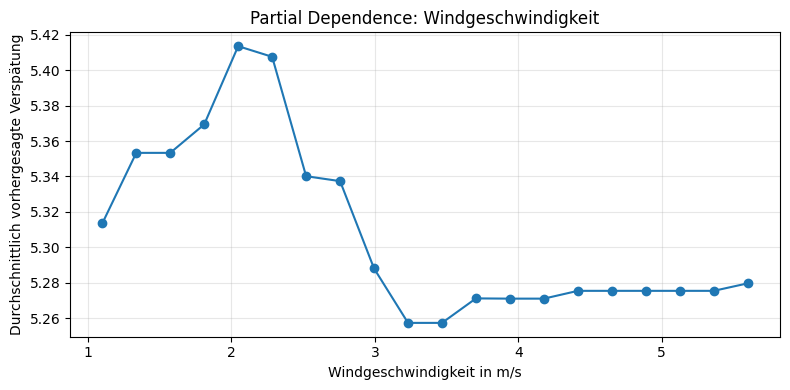

,Feature,Value,Mean Prediction
0,ff_wind_speed_ms,1.100,5.314
1,ff_wind_speed_ms,1.337,5.353
2,ff_wind_speed_ms,1.574,5.353
3,ff_wind_speed_ms,1.811,5.369
4,ff_wind_speed_ms,2.047,5.414
5,ff_wind_speed_ms,2.284,5.408
6,ff_wind_speed_ms,2.521,5.340
7,ff_wind_speed_ms,2.758,5.337
8,ff_wind_speed_ms,2.995,5.288
9,ff_wind_speed_ms,3.232,5.257


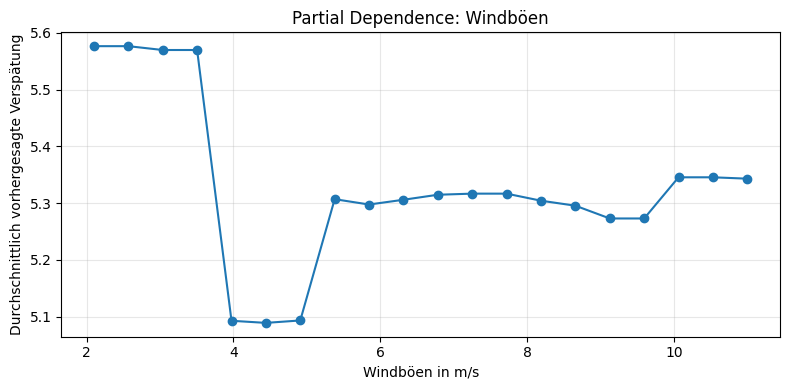

,Feature,Value,Mean Prediction
0,fx_wind_gust_ms,2.100,5.576
1,fx_wind_gust_ms,2.568,5.576
2,fx_wind_gust_ms,3.037,5.570
3,fx_wind_gust_ms,3.505,5.570
4,fx_wind_gust_ms,3.974,5.092
5,fx_wind_gust_ms,4.442,5.089
6,fx_wind_gust_ms,4.911,5.093
7,fx_wind_gust_ms,5.379,5.307
8,fx_wind_gust_ms,5.847,5.297
9,fx_wind_gust_ms,6.316,5.306


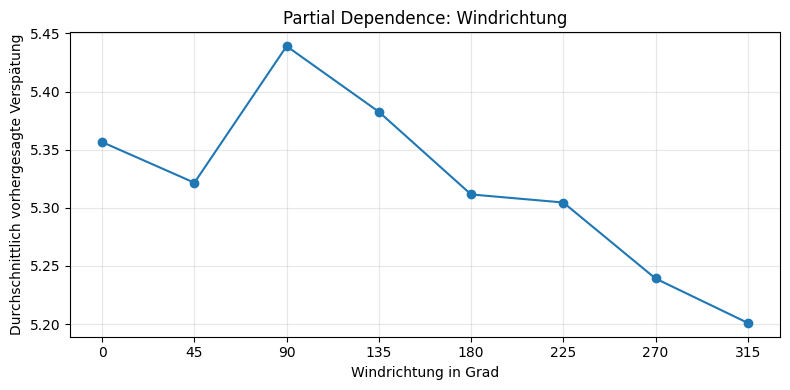

,Wind Direction Degrees,Mean Prediction
0,0,5.357
1,45,5.322
2,90,5.439
3,135,5.383
4,180,5.311
5,225,5.305
6,270,5.239
7,315,5.201


In [31]:
wind_speed_grid = evenly_spaced_quantile_grid(X_interpretation["ff_wind_speed_ms"])
wind_speed_pd = calculate_numeric_partial_dependence(
    model=xgboost_tuned_pipeline,
    X=X_interpretation,
    feature="ff_wind_speed_ms",
    values=wind_speed_grid,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(wind_speed_pd["Value"], wind_speed_pd["Mean Prediction"], marker="o")
ax.set_title("Partial Dependence: Windgeschwindigkeit")
ax.set_xlabel("Windgeschwindigkeit in m/s")
ax.set_ylabel("Durchschnittlich vorhergesagte Verspätung")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(wind_speed_pd.round(3))

wind_gust_grid = evenly_spaced_quantile_grid(X_interpretation["fx_wind_gust_ms"])
wind_gust_pd = calculate_numeric_partial_dependence(
    model=xgboost_tuned_pipeline,
    X=X_interpretation,
    feature="fx_wind_gust_ms",
    values=wind_gust_grid,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(wind_gust_pd["Value"], wind_gust_pd["Mean Prediction"], marker="o")
ax.set_title("Partial Dependence: Windböen")
ax.set_xlabel("Windböen in m/s")
ax.set_ylabel("Durchschnittlich vorhergesagte Verspätung")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(wind_gust_pd.round(3))

wind_direction_angles = [0, 45, 90, 135, 180, 225, 270, 315]
wind_direction_pd = calculate_wind_direction_partial_dependence(
    model=xgboost_tuned_pipeline,
    X=X_interpretation,
    angles_degrees=wind_direction_angles,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    wind_direction_pd["Wind Direction Degrees"],
    wind_direction_pd["Mean Prediction"],
    marker="o",
)
ax.set_title("Partial Dependence: Windrichtung")
ax.set_xlabel("Windrichtung in Grad")
ax.set_ylabel("Durchschnittlich vorhergesagte Verspätung")
ax.set_xticks(wind_direction_angles)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

wind_direction_pd.round(3)


### 9.4 Niederschlag


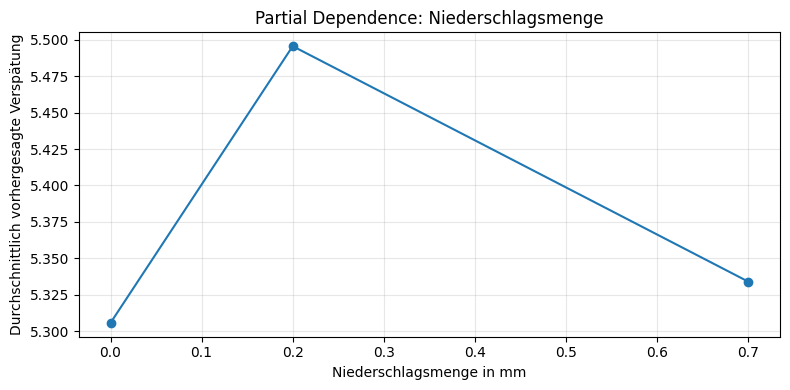

,Feature,Value,Mean Prediction
0,rr_precipitation_mm,0.0,5.306
1,rr_precipitation_mm,0.2,5.496
2,rr_precipitation_mm,0.7,5.334


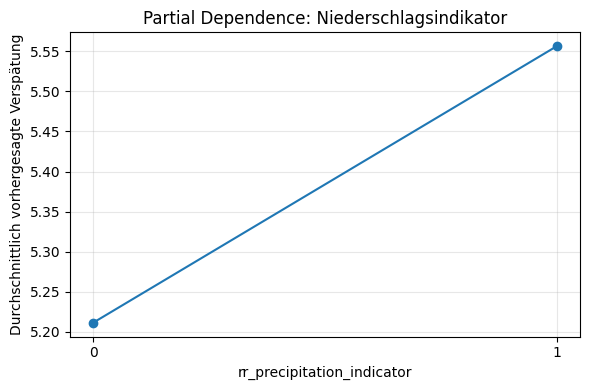

,Feature,Value,Assigned Value,Mean Prediction
0,rr_precipitation_indicator,0.0,0.0,5.211
1,rr_precipitation_indicator,1.0,1.0,5.557


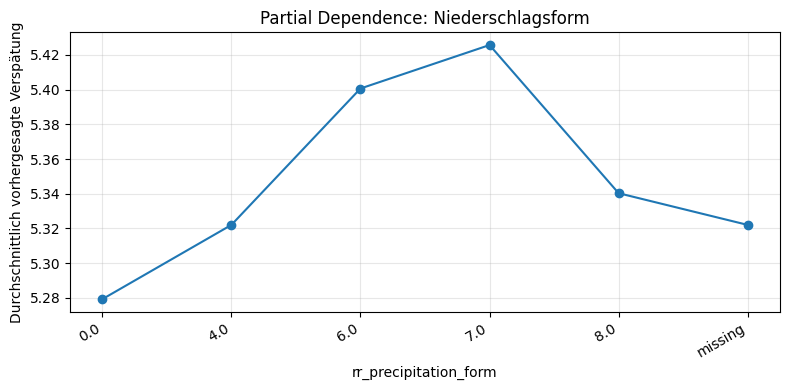

,Feature,Value,Assigned Value,Mean Prediction
0,rr_precipitation_form,0.0,0.0,5.279
1,rr_precipitation_form,4.0,4.0,5.322
2,rr_precipitation_form,6.0,6.0,5.401
3,rr_precipitation_form,7.0,7.0,5.426
4,rr_precipitation_form,8.0,8.0,5.340
5,rr_precipitation_form,missing,missing,5.322


In [32]:
precipitation_grid = observed_quantile_grid(X_interpretation["rr_precipitation_mm"])
precipitation_pd = calculate_numeric_partial_dependence(
    model=xgboost_tuned_pipeline,
    X=X_interpretation,
    feature="rr_precipitation_mm",
    values=precipitation_grid,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(precipitation_pd["Value"], precipitation_pd["Mean Prediction"], marker="o")
ax.set_title("Partial Dependence: Niederschlagsmenge")
ax.set_xlabel("Niederschlagsmenge in mm")
ax.set_ylabel("Durchschnittlich vorhergesagte Verspätung")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(precipitation_pd.round(3))

precipitation_indicator_values = sorted_observed_values(
    X_train_model["rr_precipitation_indicator"]
)
precipitation_indicator_pd = calculate_categorical_partial_dependence(
    model=xgboost_tuned_pipeline,
    X=X_interpretation,
    feature="rr_precipitation_indicator",
    values=precipitation_indicator_values,
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(
    precipitation_indicator_pd["Value"],
    precipitation_indicator_pd["Mean Prediction"],
    marker="o",
)
ax.set_title("Partial Dependence: Niederschlagsindikator")
ax.set_xlabel("rr_precipitation_indicator")
ax.set_ylabel("Durchschnittlich vorhergesagte Verspätung")
ax.set_xticks(precipitation_indicator_values)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(precipitation_indicator_pd.round(3))

precipitation_form_values = sorted_observed_values(X_train_model["rr_precipitation_form"])
precipitation_form_pd = calculate_categorical_partial_dependence(
    model=xgboost_tuned_pipeline,
    X=X_interpretation,
    feature="rr_precipitation_form",
    values=precipitation_form_values,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    precipitation_form_pd["Value"],
    precipitation_form_pd["Mean Prediction"],
    marker="o",
)
ax.set_title("Partial Dependence: Niederschlagsform")
ax.set_xlabel("rr_precipitation_form")
ax.set_ylabel("Durchschnittlich vorhergesagte Verspätung")
ax.set_xticks(range(len(precipitation_form_values)))
ax.set_xticklabels(precipitation_form_values, rotation=30, ha="right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

precipitation_form_pd.round(3)


## 10. Zusammenfassung der Modellinterpretation

Die Interpretation erfolgt anhand der gruppierten Permutation Importance und der Partial-Dependence-Auswertungen. Aufgrund der insgesamt geringen Validierungsleistung des Modells sind die Ergebnisse als Hinweise auf prognostische Zusammenhänge innerhalb des Modells und nicht als kausale Effekte zu verstehen.

Die konkrete Interpretation der ausgegebenen Tabellen und Grafiken wird anschließend manuell ergänzt.
